In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
import copy
import random



In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
normal_trans=transforms.Compose([
    transforms.Resize((128,128)),    
    transforms.ToTensor()
])

aug_trans = transforms.Compose([
    transforms.Resize((128,128)), 
    transforms.RandomCrop(128),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

In [3]:
seed = 123

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True

In [4]:
DATA_DIR = r'C:\Users\MJ\Desktop\seg'
model_algo="alexnet"


In [5]:
#建立dataset class
class ImageDataset(Dataset):
    def __init__(self, root,trans,decision_mode=False):
        super().__init__()
        self.images = ImageFolder(root=root)
        self.classes = self.images.class_to_idx.items()
        self.flag= [True] * len(self.images)
        self.decision_mode=decision_mode
        self.transform = trans

        # self.aug_trans = trans2
        # self.sum=0
    def __len__(self):
        return len(self.images)
   
    def __getitem__(self,idx):
        image, label=self.images[idx]

        # if(self.flag[idx]==True):
        image=self.transform(image)
        # else:
        #     image=self.aug_trans(image)
        #     self.sum+=1

        if(self.decision_mode==True):
            label=int(self.flag[idx])
            
        return image,label,idx
    
    def update_flag(self, idx):
        self.flag[idx] = False
    

In [6]:
#讀取資料且切分資料為train、valid、test

trainset=ImageDataset(DATA_DIR+"/seg_train",normal_trans,decision_mode=False)
validset=ImageDataset(DATA_DIR+"/seg_test",normal_trans,decision_mode=False)

train_size = len(trainset)
valid_size = len(validset)

# trainset, validset, testset = random_split(images, (train_size, valid_size, test_size))


In [7]:
# create data loaders
batch_size = 64 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()
idx2class = {v: k for k, v in trainset.classes}

In [8]:
#建立模型框架
def model_create(model_algo,data_name):
    model = getattr(models,model_algo)(weights=True)
    for param in model.features.parameters():
        param.requires_grad = False
    if(data_name=='decision'):
        class_number=2
    else:
        class_number=len(trainset.classes)

    if(model_algo=='googlenet' or model_algo=='resnet18' ):
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, class_number)
    else :
        num_ftrs = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(num_ftrs,class_number)
    
    return model

In [9]:
#模型表現
def evaluate_model(model,data_dl,size):
        model.to(device)
        ######################    
        # validate the model #
        ######################
        torch.cuda.empty_cache()
        total_loss = 0
        accu = 0
        flat_true=[]
        flat_pred=[]
        with torch.no_grad():
                model.eval()   

                for data, target,idx in data_dl:

                        data,target=data.to(device),target.to(device)
                        out= model(data)
                        _, y_pred_tag = torch.max(out, dim = 1)
                        loss = criterion(out, target)
                        
                        flat_true.extend(target.cpu().numpy())
                        flat_pred.extend(y_pred_tag.cpu().numpy())

                        total_loss+= loss.item()*data.size(0)
                        correct=torch.sum(y_pred_tag == target).item()
                        accu += correct      

                total_loss=total_loss/size
                accu=accu/size
        confusion_matrix_valid= pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
        return total_loss,accu,confusion_matrix_valid

In [10]:
    
def evaluate_model_TF(model,TorF):
    num=0
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
   
    with torch.no_grad():
            model_0.eval()   
            for data, target,idx in valid_dl:

                    data,target=data.to(device),target.to(device)
                    out_growth= model_0(data)
                    _, decision_tag = torch.max(out_growth, dim = 1)

                    for result,d,t in zip(torch.eq(target,decision_tag),data,target):
                            if (TorF == "T" and result.cpu().numpy()) or (TorF == "F" and not result.cpu().numpy()):
                                out = model(d.unsqueeze(0))
                                _, y_pred_tag = torch.max(out, dim = 1)
                                loss=criterion(out,t.unsqueeze(0))
                                num+=1
                        
                                total_loss+= loss.item()
                                correct=torch.sum(y_pred_tag == t).item()
                
                                accu += correct 
                                flat_true.extend(t.unsqueeze(0).cpu().numpy())
                                flat_pred.extend(y_pred_tag.cpu().numpy()) 

    valid_loss=total_loss/num
    valid_accu=accu/num                                  
    print(f"Model_{TorF} valid loss={valid_loss}, accu={valid_accu},sample_number={num}") 
    confusion_matrix_valid= pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return valid_loss,valid_accu,confusion_matrix_valid

In [11]:

def evaluate_model_decision(model):
        correct=0
        flat_true=[]
        flat_pred=[]
        decision_valid_accu=0
        with torch.no_grad():
                model_0.eval()   
                for data, target,idx in valid_dl:

                        data,target=data.to(device),target.to(device)
                        out_growth= model_0(data)   #原始model
                        _, y_pred_tag = torch.max(out_growth, dim = 1)

                        out_predict= model(data)  #預測要用哪個model
                        _, predict = torch.max(out_predict, dim = 1)
        
                        for pred,result in zip(predict,torch.eq(target,y_pred_tag)):
                                if(result==pred):
                                        correct+=1
                                flat_true.append(result.cpu().numpy())
                                flat_pred.append(pred.cpu().numpy())

        decision_valid_accu=correct/valid_size

        print("decision_valid accu=",decision_valid_accu) 
        confusion_matrix_decision_valid= pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
        return  decision_valid_accu,confusion_matrix_decision_valid

In [12]:
#訓練模型
def trainer(epochs,model,criterion,optim,data_dl,data_name):
        train_accus=[]
        val_accus=[]
        best_val_accu = 0.0
        epochs_without_improvement = 0
        overfitting = 0
        patience=5
       

        for epoch in range(epochs):
                
                train_loss=0
                model.to(device)
                model.train()
                ###################
                # train the model #
                ###################
                for data, target,idx in data_dl:
                        
                        optim.zero_grad()
                        data,target=data.to(device),target.to(device)  #將data、target放到gpu上
                      
                        out = model(data)
                        # _, y_pred_tag = torch.max(out, dim = 1)  
                        
                        loss = criterion(out, target)
                        loss.backward()
                        optim.step()
                        # print(target)
                
                      
                train_loss,train_accu,_=evaluate_model(model,data_dl,len(data_dl.dataset))
                print(f"Epoch={epoch},train_loss={train_loss},train_accu={train_accu}")
                train_accus.append(train_accu)
                
                if(data_name=="T" or data_name=="F"):  
                        
                        val_loss,val_accu,_=evaluate_model_TF(model,data_name)
                elif(data_name=="decision"):
                        val_accu,_=evaluate_model_decision(model)
                else:
                        val_loss,val_accu,_=evaluate_model(model,valid_dl,valid_size)
                        print(f"Epoch={epoch},valid_loss={val_loss},valid_accu={val_accu}")

                val_accus.append(val_accu)
        
                # Early stopping
                if val_accu > best_val_accu:
                        best_val_accu = val_accu
                        epochs_without_improvement = 0
                        best_model=copy.deepcopy(model)
                        print(f"{epochs_without_improvement}")
                # elif (train_accu-best_val_accu>0.02):
                #         overfitting += 1
                        
                else:
                        epochs_without_improvement += 1

                if epochs_without_improvement >= patience:
                        print(f"{epochs_without_improvement} Early stopping!")
                        break
                # elif overfitting >= patience:
                #         print("Early stopping overfit!")
                #         break
                
                torch.save(best_model, f"model_{model_algo}_{data_name}_{epoch}.pth")               
        plt.plot(train_accus,'-o')
        plt.plot(val_accus,'-o')

        plt.xlabel('epoch')
        plt.ylabel('Accuracy')
        plt.legend(['Train','Valid'])
        plt.show()
        torch.save(best_model, f"model_{model_algo}_{data_name}.pth")  
        return best_model
                

In [13]:
#將模型建立框架後並訓練
def model_train(model_algo,data_dl,data_name,epochs,class_weight=None):
    
    model=model_create(model_algo,data_name)
    if(data_name=="decision"):
        trainset.decision_mode=True
        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4,weight_decay=1e-3)
        criterion = nn.CrossEntropyLoss(weight=class_weight)
        
        model=trainer(epochs,model,criterion,optim,data_dl,data_name)
        trainset.decision_mode=False
    else:
        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        model=trainer(epochs,model,criterion,optim,data_dl,data_name)
    torch.save(model, f"model_{model_algo}_{data_name}.pth")
    torch.cuda.empty_cache() 
    return model

In [14]:
# model_0=model_train(model_algo,train_dl,"0",20)
model_0 = torch.load(f'model_{model_algo}_0_2.pth')

In [15]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size)
train_loss,train_accu

(0.23670162478199333, 0.9225452472566624)

In [16]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size)
valid_loss,valid_accu

(0.3260466568470001, 0.888)

In [17]:
#將資料切分成true and false
def split_data(model_0,data_dl):
    model_0.eval()
  
    indexF=[]
    indexT=[]
    with torch.no_grad():

        for (data,target,idx) in data_dl:
            data,target=data.cuda(),target.cuda()
            out = model_0(data)
            _, y_pred_tag = torch.max(out, dim = 1) 
            # print(y_pred_tag)
            for idx,t,tag in zip(idx,target,y_pred_tag):

                if(t==tag):
                    indexT.append(idx.cpu().numpy().item())
                    
                else:
                    indexF.append(idx.cpu().numpy().item())
                    trainset.update_flag(idx)
            
        torch.cuda.empty_cache() 
    return indexF,indexT

In [18]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
indexF,indexT=split_data(model_0,train_dl)

# Fdataset=Subset(trainset, indexF)
# Tdataset=Subset(trainset, indexT)
# Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
# Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)


In [19]:
len(indexF),len(indexT)

(1087, 12947)

In [20]:
targets=[target for _,target,_ in trainset]
flag_counts=[len(indexF),len(indexT)]
total_sample=sum(flag_counts)
w=[total_sample / count for count in flag_counts] 
weights = [w[0]-8 if t == 0 else w[1] for t in targets]
w[0]+=4
w=torch.tensor(w).cuda()

In [21]:
w

tensor([16.9108,  1.0840], device='cuda:0')

In [22]:
sampler = WeightedRandomSampler(weights, len(trainset), replacement=True)
trainset.decision_mode=True
decision_dl = DataLoader(trainset, batch_size=64,sampler=sampler)
trainset.decision_mode=False

In [23]:
# trainset.decision_mode=True
# data=[data.numpy() for data ,_,_ in trainset]
# targets=[target for _,target,_ in trainset]
# trainset.decision_mode=False

c:\Users\MJ\anaconda3\envs\MJ\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.6388543356054441,train_accu=0.6008978195810175
decision_valid accu= 0.5173333333333333
0
Epoch=1,train_loss=0.7466023800480786,train_accu=0.5680490237993444
decision_valid accu= 0.47533333333333333
Epoch=2,train_loss=0.3670947783707179,train_accu=0.7840245118996723
decision_valid accu= 0.679
0
Epoch=3,train_loss=0.6135872270674622,train_accu=0.6271911073108166
decision_valid accu= 0.49533333333333335
Epoch=4,train_loss=0.41943860314367026,train_accu=0.7435513752315804
decision_valid accu= 0.624
Epoch=5,train_loss=0.35171230860002467,train_accu=0.774975060567194
decision_valid accu= 0.6296666666666667
Epoch=6,train_loss=0.48122215881313,train_accu=0.7037907937865184
decision_valid accu= 0.548
Epoch=7,train_loss=0.34325084288575225,train_accu=0.8037622915775973
decision_valid accu= 0.678
5 Early stopping!


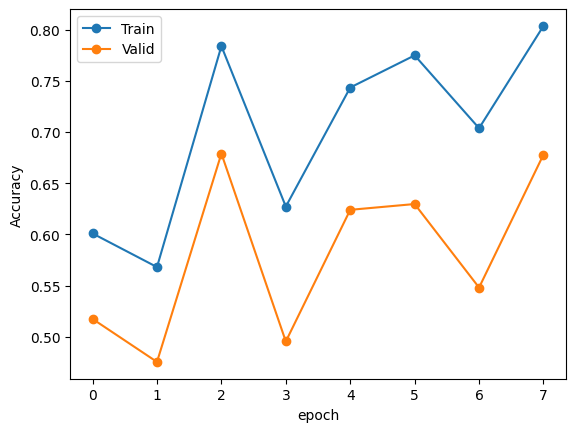

In [24]:
model_decision=model_train(model_algo,decision_dl,"decision",50,w)
# model_decision = torch.load(f'model_{model_algo}_decision.pth')

In [25]:
trainset.decision_mode=True
decision_F=[]
decision_T=[]
model_decision.eval()
model_0.eval()
sumF=0
sumT=0
with torch.no_grad():
    for (data,target,idx) in decision_dl:
        data,target=data.cuda(),target.cuda()
        out = model_decision(data)
        _, decision_tag = torch.max(out, dim = 1) 

        for idx,dtag ,t in zip(idx,decision_tag,target):
            
            if(dtag==t==1):
                sumT+=1
                decision_T.append(idx.cpu().numpy().item())
            elif(dtag==t==0):
                decision_F.append(idx.cpu().numpy().item())
            else:
                decision_T.append(idx.cpu().numpy().item())
                decision_F.append(idx.cpu().numpy().item())
                
    torch.cuda.empty_cache() 
    trainset.decision_mode=False
    
Fdataset=Subset(trainset, decision_F)
Tdataset=Subset(trainset, decision_T)
Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)


In [26]:
sumT

9775

In [27]:
len(decision_F),len(Tdataset)

(4259, 12918)

In [28]:
def evaluate_model_TF(model,TorF):
    num=0
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
   
    with torch.no_grad():
            model_0.eval()   
            for data, target,idx in valid_dl:

                    data,target=data.to(device),target.to(device)
                    out_growth= model_decision(data)
                    _, decision_tag = torch.max(out_growth, dim = 1)

                    for result,d,t in zip(decision_tag,data,target):
                            if (TorF == "T" and result.cpu().numpy()) or (TorF == "F" and not result.cpu().numpy()):
                                out = model(d.unsqueeze(0))
                                _, y_pred_tag = torch.max(out, dim = 1)
                                loss=criterion(out,t.unsqueeze(0))
                                num+=1
                        
                                total_loss+= loss.item()
                                correct=torch.sum(y_pred_tag == t).item()
                
                                accu += correct 
                                flat_true.extend(t.unsqueeze(0).cpu().numpy())
                                flat_pred.extend(y_pred_tag.cpu().numpy()) 

    valid_loss=total_loss/num
    valid_accu=accu/num                                  
    print(f"Model_{TorF} valid loss={valid_loss}, accu={valid_accu},sample_number={num}") 
    confusion_matrix_valid= pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return valid_loss,valid_accu,confusion_matrix_valid

c:\Users\MJ\anaconda3\envs\MJ\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.16804602158399057,train_accu=0.934664808793931
Model_T valid loss=0.3361396011545421, accu=0.8971542685971043,sample_number=2003
0
Epoch=1,train_loss=0.05843600883611604,train_accu=0.9848273726583062
Model_T valid loss=0.2929325789065499, accu=0.9161258112830754,sample_number=2003
0
Epoch=2,train_loss=0.034635445680097264,train_accu=0.9928007431490943
Model_T valid loss=0.27434453629192673, accu=0.9226160758861708,sample_number=2003
0
Epoch=3,train_loss=0.04500415101967479,train_accu=0.9833565567425298
Model_T valid loss=0.3427504103444421, accu=0.9171243135297055,sample_number=2003
Epoch=4,train_loss=0.02363060303245799,train_accu=0.9941941477008824
Model_T valid loss=0.3423440397863979, accu=0.9141288067898152,sample_number=2003
Epoch=5,train_loss=0.021796056564149242,train_accu=0.9945037931568355
Model_T valid loss=0.3515671103347211, accu=0.9121318022965552,sample_number=2003
Epoch=6,train_loss=0.008689382380051364,train_accu=0.9982969499922588
Model_T valid lo

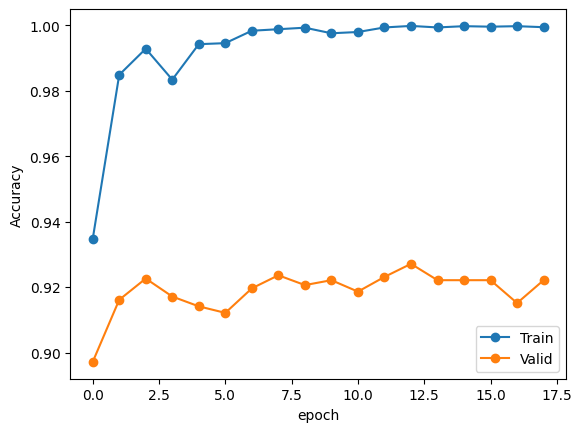

In [29]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,"T",20)
# model_T=torch.load(f'model_{model_algo}_T.pth')

In [30]:
# targets=[target for _,target,_ in Fdataset]
# import collections
# class_counts = collections.Counter(targets)
# total_sample=len(Fdataset)

# w = [0] * 6

# for i,count in class_counts.items():
#     w[i]=total_sample/count

# w[1]-=40

# for i in range(2,6):
#     w[i]+=40
   
# w=torch.tensor(w).cuda()

c:\Users\MJ\anaconda3\envs\MJ\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.48961179478679584,train_accu=0.8269546841981685
Model_F valid loss=0.6378007403228324, accu=0.7542627883650953,sample_number=997
0
Epoch=1,train_loss=0.37821888960031985,train_accu=0.88142756515614
Model_F valid loss=0.5693748838869797, accu=0.7853560682046138,sample_number=997
0
Epoch=2,train_loss=0.2604528162457848,train_accu=0.9175862878610003
Model_F valid loss=0.5327531973678802, accu=0.7973921765295887,sample_number=997
0
Epoch=3,train_loss=0.17186018650689633,train_accu=0.9492838694529232
Model_F valid loss=0.5833196752752146, accu=0.7622868605817452,sample_number=997
Epoch=4,train_loss=0.1143158457807656,train_accu=0.9699459967128434
Model_F valid loss=0.5629732390832946, accu=0.7853560682046138,sample_number=997
Epoch=5,train_loss=0.09725995815417442,train_accu=0.9755811223291853
Model_F valid loss=0.6290971384679637, accu=0.765295887662989,sample_number=997
Epoch=6,train_loss=0.05445799049244545,train_accu=0.9884949518666354
Model_F valid loss=0.631499705

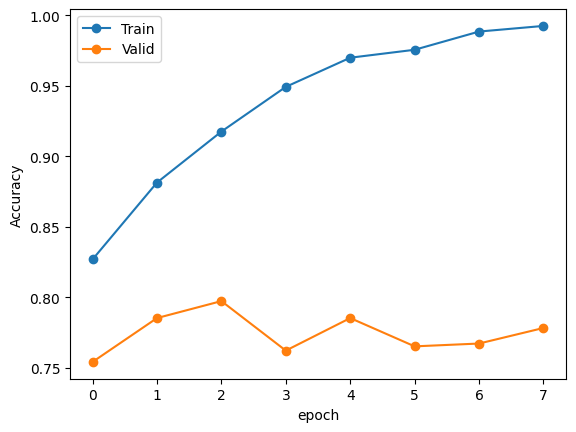

In [31]:
model_F=model_train(model_algo,Fdl,"F",20)
# model_F=torch.load(f'model_{model_algo}_F.pth')

In [32]:
torch.cuda.empty_cache()

In [33]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset))
T_loss,T_accu

(0.002215267381241381, 0.9997677659080353)

In [34]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset))
F_loss,F_accu

(0.26045281832753897, 0.9175862878610003)

In [35]:
trainset.decision_mode=True
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,train_size)
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"buildings":"False","forest":"True"}, index={"buildings":"False","forest":"True"})
trainset.decision_mode=False
decision_loss,decision_accu

(0.36435662252671597, 0.7868747327917913)

In [36]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model_TF(model_T,"T")
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model_TF(model_F,"F")


Model_T valid loss=0.41116039668353366, accu=0.927109335996006,sample_number=2003
Model_F valid loss=0.5327531973678802, accu=0.7973921765295887,sample_number=997


In [37]:
decision_valid_accu,confusion_matrix_decision_valid=evaluate_model_decision(model_decision )
# confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})

decision_valid accu= 0.679


In [38]:
#全部模型裝在一起的表現
def total_model_evaluate(data_dl,size):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]


    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out = model_decision(data)
            _, y_pred_tag = torch.max(out, dim = 1)
            
        
            for pred,d,t in zip(y_pred_tag,data,target):
                if(pred==0):
                    outputs.append(model_F(d.unsqueeze(0)))
                    

                else:
                    outputs.append(model_T(d.unsqueeze(0)))
                    
           
            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)
        

            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())
            
            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total

In [39]:
total_train_loss,total_train_accu,confusion_matrix_total_train=total_model_evaluate(train_dl,train_size)
total_train_loss,total_train_accu

(0.2608771866827978, 0.9248254239703577)

In [40]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid=total_model_evaluate(valid_dl,valid_size)
total_valid_loss,total_valid_accu

(0.45156972408294677, 0.884)

In [41]:
def plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,model_name):
    fig = plt.figure(figsize=(15, 5))
    ax1, ax2 = fig.add_subplot(121), fig.add_subplot(122)

    sns.heatmap(confusion_matrix_train, annot=True, fmt='',cbar=False,ax=ax1,square=True).set(title=f"{model_algo}_{model_name} train confusion matrix", xlabel="Predicted Label", ylabel="True Label")
    sns.heatmap(confusion_matrix_valid, annot=True, fmt='',ax=ax2,square=True).set(title=f"{model_algo}_{model_name} valid confusion matrix", xlabel="Predicted Label", ylabel="True Label")


In [42]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu]
valid_losses=[valid_loss,"NA",T_valid_loss,F_valid_loss,total_valid_loss]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu]

In [43]:
model_algos=['Model_0',"Model_decision","Model_T","Model_F","Total_Model"]
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
df

,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.236702,0.922545,0.326047,0.888000
1,Model_decision,0.364357,0.786875,NA,0.679000
2,Model_T,0.002215,0.999768,0.41116,0.927109
3,Model_F,0.260453,0.917586,0.532753,0.797392
4,Total_Model,0.260877,0.924825,0.45157,0.884000


In [44]:
len(Fdataset),len(Tdataset)

(4259, 12918)

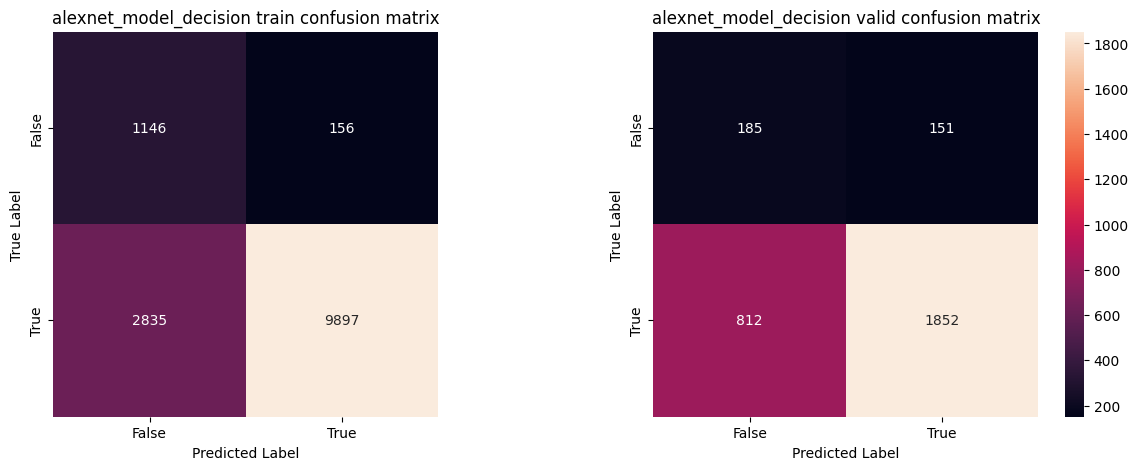

In [45]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision")

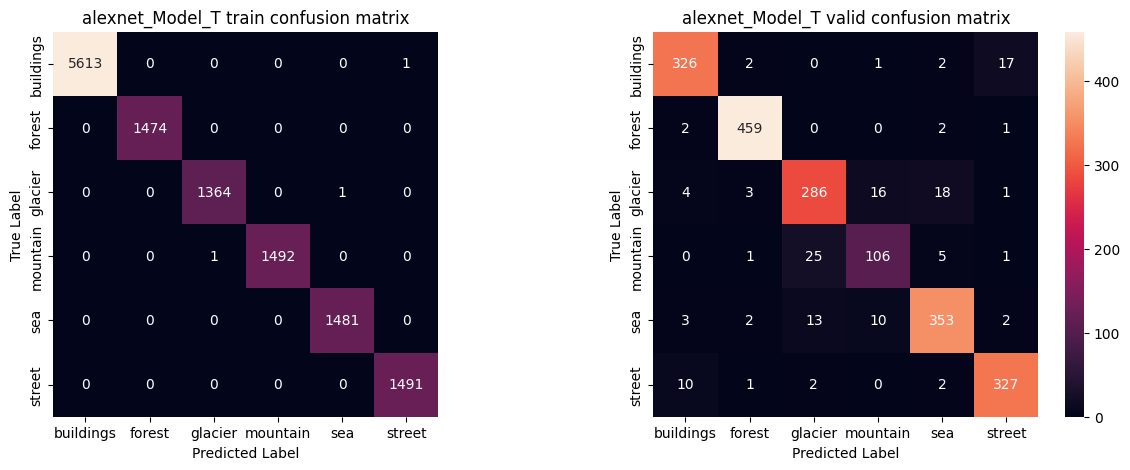

In [46]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T")

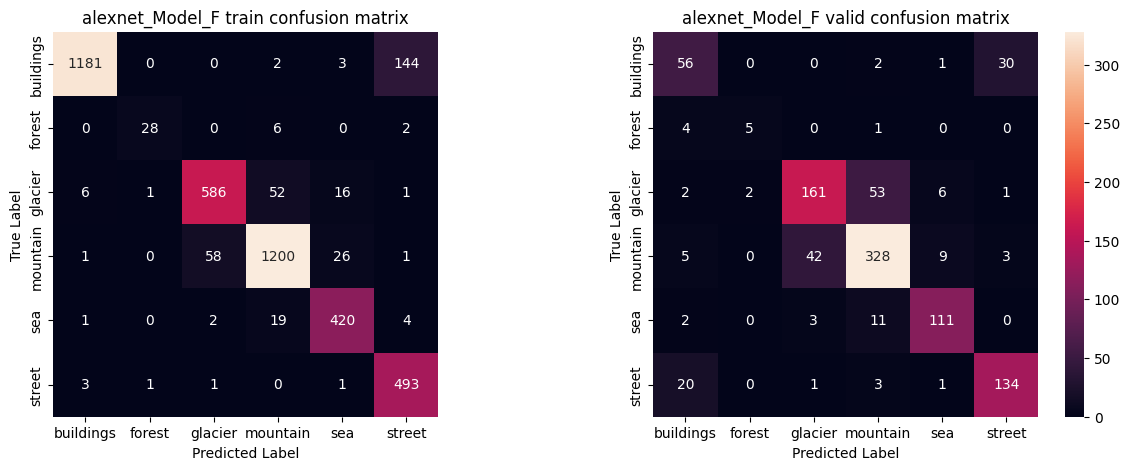

In [47]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F")

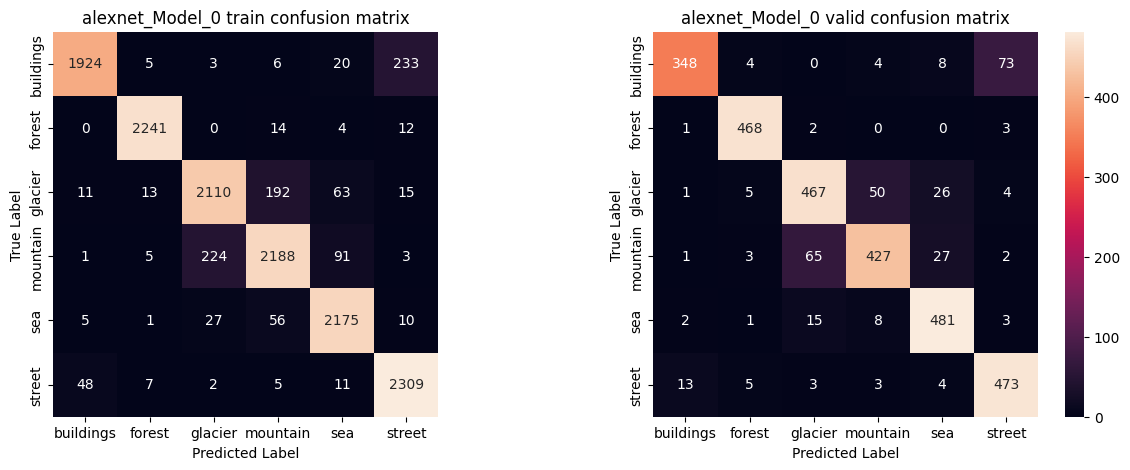

In [48]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0")

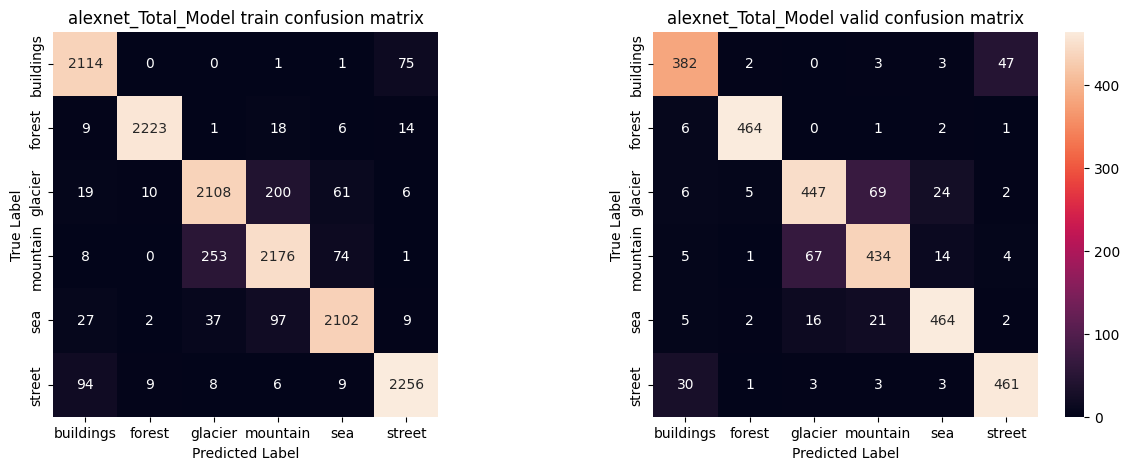

In [49]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model")